# 第 9 章 · BPE

「鲁迅写了狂人日记」：逐次合并最高频 byte pair。

配套交互演示：[章节网页](../ch9.html)

## 本节目标

- 统计 pair 频次
- 逐步 merge
- GIF 看 token 序列变化

## 1. 初始 token

语料先切成字符级 token；统计相邻 pair 出现次数。

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "labs").exists() and (ROOT.parent / "labs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch09"))
import matplotlib.pyplot as plt
from common.mpl_setup import configure_matplotlib
configure_matplotlib()
from IPython.display import display, Image
from bpe import *
from common.codelens import print_frames as print_codelens

In [2]:
demo_first_merge()

初始 token: ['鲁', '迅', '写', '了', '狂', '人', '日', '记']
最高频 byte pair TOP3:
  (鲁,迅): 1 次
  (迅,写): 1 次
  (写,了): 1 次

第 1 次合并 ['日', '记'] → 日记


## 2. 逐步合并

**BPE**

```text
while vocab large:
  pair = argmax count(a,b)
  merge pair -> new token
```

In [3]:
bpe_frames = codelens_bpe_merges()

In [4]:
print_codelens(bpe_frames)

── Step 0 ── 字符级切分
   执行: tokens = initial
   tokens = ['鲁', '迅', '写', '了', '狂', '人', '日', '记']
   pairs_top3 = [(('鲁', '迅'), 1), (('迅', '写'), 1), (('写', '了'), 1)]

── Step 1 ── 第 1 次合并（频次 12）
   执行: merge ['日', '记'] → 日记
   合并对 = ['日', '记']
   合并后 = ['鲁', '迅', '写', '了', '狂', '人', '日记']
   与网页一致 = True

── Step 2 ── 第 2 次合并（频次 8）
   执行: merge ['狂', '人'] → 狂人
   合并对 = ['狂', '人']
   合并后 = ['鲁', '迅', '写', '了', '狂人', '日记']
   与网页一致 = True

── Step 3 ── 第 3 次合并（频次 6）
   执行: merge ['鲁', '迅'] → 鲁迅
   合并对 = ['鲁', '迅']
   合并后 = ['鲁迅', '写', '了', '狂人', '日记']
   与网页一致 = True



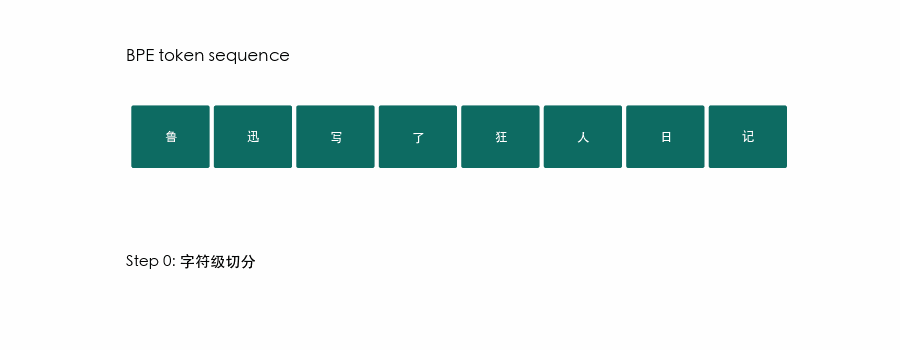

In [5]:
animate_bpe_merges()

In [6]:
display(steps_table())

,步骤,合并对,序列
0,0,—,鲁 / 迅 / 写 / 了 / 狂 / 人 / 日 / 记
1,1,日+记(12次),鲁 / 迅 / 写 / 了 / 狂 / 人 / 日记
2,2,狂+人(8次),鲁 / 迅 / 写 / 了 / 狂人 / 日记
3,3,鲁+迅(6次),鲁迅 / 写 / 了 / 狂人 / 日记


In [7]:
print_steps()

语料提示：鲁迅 写 了 狂人 日记

| 步骤 | 合并对 | 合并后 token 序列 | 与网页一致 |
|------|--------|-------------------|------------|
| 0 字符级 | — | 鲁 / 迅 / 写 / 了 / 狂 / 人 / 日 / 记 | ✓ |
| 1 | 日+记（12 次） | 鲁 / 迅 / 写 / 了 / 狂 / 人 / 日记 | ✓ |
| 2 | 狂+人（8 次） | 鲁 / 迅 / 写 / 了 / 狂人 / 日记 | ✓ |
| 3 | 鲁+迅（6 次） | 鲁迅 / 写 / 了 / 狂人 / 日记 | ✓ |

最终子词表：鲁迅 / 写 / 了 / 狂人 / 日记  (✓ 与网页一致)


**思考** · 第一次合并哪一对？

<details><summary>查看答案</summary>

见 demo_first_merge 最高频 pair。

</details>

## 3. 与网页验证

每步 `与网页一致` 字段应为 True。

## 小结

BPE 由高频 pair 迭代合并子词。对照 [ch9.html](../ch9.html)。

## 练习

1. 为何先合并高频 pair？
2. 中文 BPE 与英文有何不同？